In [16]:
import os
import pickle
import sys
sys.path.append(os.path.join(os.getcwd(), "notebooks/lineage_tracing"))
import lineage_tracing_utilities as lt
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gzip

from metient.util import plotting_util as plutil
from metient.util import vertex_labeling_util as vutil
from metient import metient as met
output_dir = "/data/morrisq/divyak/projects/metient/notebooks/lineage_tracing/outputs"
lt_dir = "/data/morrisq/divyak/projects/metient/data/quinn_lt_2021/"

RUN_NAME = "2048bs_200runs_05142025_r1"
metient_results_dir = os.path.join(lt_dir, "metient_outputs", RUN_NAME)

In [27]:
    
def site_specifc_clonality(V, A, idx_to_label, sites=None):
    '''
    If all nodes can be reached from the top level node in the seeding clusters,
    returns monophyletic, else polyphyletic
    '''
    V, A = plutil.prep_V_A_inputs(V, A)
    all_seeding_clusters = plutil.seeding_clusters(V, A, idx_to_label, sites)
    if len(all_seeding_clusters) == 0: # no seeding
        return "no seeding"
    
    site_clonality = "monoclonal" if len(all_seeding_clusters) == 1 else "polyclonal"

    return site_clonality

def weighted_phyleticity(pkl, A, P, depths, node_infos, probabilities, sites):

    # probabilities, Vs, As, node_infos = _get_weighted_classification_data(pkl)
    
    Vs = pkl['clone_tree_labeling_matrices']
    phyleticities = []
    for i in range(len(Vs)):
        phyleticities.append(plutil.fast_phyleticity(Vs[i], A, P, node_infos[i], depths, sites))
    
    return plutil.weighted_classification(probabilities, phyleticities)

def founding_clone_tissue(V, A, ordered_sites):
    A = A.coalesce()
    gl_node = vutil.get_root_index(A)
    root_node = int(A[gl_node].indices()[0][0])
    root_node_children = A[root_node].coalesce().indices()[0]
    assert len(root_node_children) > 1
    root_tissue_idx = np.where(V[:,root_node]!=0)[0][0]
    return ordered_sites[root_tissue_idx]


In [29]:
%%prun -s cumtime

cass_results_dir = os.path.join(lt_dir, "cassiopeia_outputs")

clones = [int(f[:-len('_LL.pkl.gz')]) for f in os.listdir(metient_results_dir) if f.endswith('_LL.pkl.gz')]
clones = sorted(clones)
print(len(clones), "clones")

data = {
    "clone": [],
    "probability": [],
    "phyleticity": [],
    "tissue": [],
    "highest_node_is_founding_clone": [],
    "site clonality": [],
    "tree_idx": [],
}

tissue_to_phyleticity_and_prob = {}
for clone in clones:
    print("\nClone", clone)
    with gzip.open(os.path.join(metient_results_dir,f"{clone}_LL.pkl.gz") ,"rb") as f:
        pckl = pickle.load(f)
        
    num_solutions = len(pckl['clone_tree_labeling_matrices'])
    print(f"{num_solutions} solutions")
    ordered_sites = pckl['ordered_anatomical_sites']
    losses = pckl['losses']
    A = met.adjacency_matrix_from_parents(pckl['full_adjacency_matrices'][0])
    print(A.shape)
    P = vutil.path_matrix(A, remove_self_loops=False).to_dense()
    depths = plutil.compute_depths(A, P)
    probs = plutil.losses_to_probabilities(losses, temperature=0.05)
    print(probs)
    mig_graphs = []
    pars_metrics = []
    unnormed_tissue_trans = torch.zeros((len(lt.TISSUE_ORDER),len(lt.TISSUE_ORDER)))
    node_infos = [vutil.MigrationHistoryNodeCollection.from_dict(x) for x in pckl['node_info']]
    for tissue in ordered_sites:
        phyl = weighted_phyleticity(pckl, A, P, depths, node_infos, probs, [ordered_sites.index(tissue)])
        for tree_idx,prob in enumerate(probs):
            V = pckl['clone_tree_labeling_matrices'][tree_idx]
            node_info = node_infos[tree_idx]
            tissue_of_founding_clone = founding_clone_tissue(V,A,ordered_sites)
            
            site_clonality = site_specifc_clonality(V, A, node_info, sites=[ordered_sites.index(tissue)])

            # phyl, clonality = fast_phyleticity_and_site_clonality(V, A, P, node_info, depths, sites=[ordered_sites.index(tissue)])
            
            #print("solution:", tree_idx, "tissue:", tissue, "phyleticity:", phyl, "site clonality", clonality)
            data["clone"].append(clone)
            data["probability"].append(prob)
            data["phyleticity"].append(phyl)
            data["tissue"].append(tissue)
            data["site clonality"].append(site_clonality)
            data["highest_node_is_founding_clone"].append(tissue_of_founding_clone==tissue)
            data["tree_idx"].append(tree_idx)

df = pd.DataFrame(data)
df.to_csv(os.path.join(output_dir, f"phyleticity_clonality_classifications_{RUN_NAME}.tsv"), sep='\t', index=False)

100 clones

Clone 1
71 solutions
torch.Size([26541, 26541])


/lila/data/morrisq/divyak/projects/metient/metient/util/data_extraction_util.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parents = torch.tensor(parents)[mask]


[9.99964399e-01 2.66363999e-06 2.60314507e-06 2.58007332e-06
 2.56755721e-06 2.38063638e-06 2.27542191e-06 2.27243432e-06
 2.11141422e-06 2.05479492e-06 1.73886559e-06 1.73826847e-06
 1.50476409e-06 1.48641098e-06 1.46735748e-06 1.26100972e-06
 1.08039992e-06 7.44704128e-07 4.21323721e-07 2.87452684e-07
 2.85735600e-07 2.36169116e-07 2.08186675e-07 1.55417921e-07
 1.44304196e-07 1.29224980e-07 1.01969383e-07 9.91195560e-08
 9.23278927e-08 8.87755059e-08 7.17997376e-08 7.17592363e-08
 6.75073381e-08 6.62132256e-08 6.26828842e-08 5.49177651e-08
 5.11143833e-08 3.39899383e-08 3.22344695e-08 3.04030489e-08
 2.57643037e-08 2.23089983e-08 1.86450198e-08 1.59876741e-08
 1.59017923e-08 1.55075920e-08 1.43493753e-08 1.37902410e-08
 1.37199025e-08 1.15717325e-08 1.09248739e-08 1.02346095e-08
 9.98761901e-09 9.79890758e-09 8.74854604e-09 8.31999356e-09
 6.96619089e-09 5.51250085e-09 4.84100315e-09 4.00750086e-09
 3.99613447e-09 3.72892069e-09 3.69984255e-09 3.29558757e-09
 2.65172637e-09 2.633961

         26596804 function calls (26588747 primitive calls) in 2636.648 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.001    0.000 2636.648 2636.648 {built-in method builtins.exec}
        1    1.691    1.691 2636.647 2636.647 <string>:1(<module>)
    16414   21.850    0.001 2471.678    0.151 plotting_util.py:206(seeding_clusters)
    16414 1132.191    0.069 2434.076    0.148 plotting_util.py:150(migration_edges)
     8207    0.125    0.000 1264.532    0.154 3776650231.py:1(site_specifc_clonality)
      518    0.104    0.000 1256.461    2.426 3776650231.py:15(weighted_phyleticity)
     8207    0.475    0.000 1256.336    0.153 plotting_util.py:506(fast_phyleticity)
    16414    0.147    0.000  913.517    0.056 _tensor.py:34(wrapped)
    16414    0.134    0.000  913.335    0.056 _tensor.py:907(__rsub__)
    16414  913.201    0.056  913.201    0.056 {built-in method torch.rsub}
    16414  239.905    0.015  3

In [30]:
def consensus_tissue_by_weighted_average(df):
    # Step 1: Filter rows where highest_node_is_founding_clone is True
    filtered_df = df[df['highest_node_is_founding_clone'] == True]

    # Step 2: Group by clone and tissue to calculate the weighted sum of probabilities
    weighted_avg_df = (filtered_df.groupby(['clone', 'tissue'])
                       .agg(weighted_probability=('probability', 'sum'))
                       .reset_index())

    # Step 3: For each clone, find the tissue with the highest weighted probability
    consensus_tissue_df = (weighted_avg_df.loc[weighted_avg_df.groupby('clone')['weighted_probability'].idxmax()]
                           .rename(columns={'tissue': 'consensus_tissue'}))

    # Step 4: Return DataFrame with clone and the consensus tissue
    return consensus_tissue_df[['clone', 'consensus_tissue', 'weighted_probability']]

def percentage_founding_clones_by_tissue(df):
    # Step 1: Get the consensus tissue for each clone using the weighted average function
    consensus_df = consensus_tissue_by_weighted_average(df)
    
    # Step 2: Count how many times each tissue is the consensus founding clone
    tissue_counts = consensus_df['consensus_tissue'].value_counts()
    
    # Step 3: Calculate the percentage for each tissue
    total_clones = len(consensus_df)  # Total number of unique clones
    tissue_percentage = (tissue_counts / total_clones) * 100
    
    # Step 4: Return the percentages as a DataFrame
    tissue_percentage_df = tissue_percentage.reset_index()
    tissue_percentage_df.columns = ['tissue', 'percentage_founding_clone']
    
    return tissue_percentage_df

df = pd.read_csv(os.path.join(output_dir, f"phyleticity_clonality_classifications_{RUN_NAME}.tsv"), sep='\t')
percent_founding_clones_by_tissue = percentage_founding_clones_by_tissue(df)
percent_founding_clones_by_tissue

,tissue,percentage_founding_clone
0,M1,62.000
1,M2,14.000
2,RE,10.000
3,LL,10.000
4,RW,3.000
5,Liv,1.000


In [31]:
# Function to compute the weighted classification of phyleticity for each clone-tissue combo
def weighted_classification_phyleticity(group):
    return weighted_classification(group, "phyleticity")

def weighted_classification_clonality(group):
    return weighted_classification(group, "site clonality")

def weighted_classification(group,attr):
    # Get the unique phyleticity values
    phyleticities = group[attr].unique()
    
    # Initialize a dictionary to hold the weighted sum of probabilities for each phyleticity
    weighted_probs = {phyleticity: 0 for phyleticity in phyleticities}
    
    # Sum the weighted probabilities for each phyleticity
    for index, row in group.iterrows():
        weighted_probs[row[attr]] += row['probability']
    
    # Determine the phyleticity with the highest total weight
    most_probable_phyleticity = max(weighted_probs, key=weighted_probs.get)
    
    # Return the weighted classification
    return pd.Series({
        f'weighted_{attr}': most_probable_phyleticity,
        'weighted_probabilities': weighted_probs
    })


# Group by 'clone' and 'tissue', then apply the weighted classification function
weighted_phyleticity = df.groupby(['clone', 'tissue']).apply(weighted_classification_phyleticity).reset_index()
weighted_clonality = df.groupby(['clone', 'tissue']).apply(weighted_classification_clonality).reset_index()

weighted_clonality


,clone,tissue,weighted_site clonality,weighted_probabilities
0,1,LL,polyclonal,"{'polyclonal': 0.9999999634323613, 'monoclonal..."
1,1,Liv,polyclonal,{'polyclonal': 0.999999999999999}
2,1,M1,polyclonal,{'polyclonal': 0.999999999999999}
3,1,M2,polyclonal,{'polyclonal': 0.999999999999999}
4,1,RE,polyclonal,{'polyclonal': 0.999999999999999}
...,...,...,...,...
513,100,Liv,polyclonal,{'polyclonal': 1.0000000000000002}
514,100,M1,monoclonal,"{'monoclonal': 0.9999999979388464, 'polyclonal..."
515,100,M2,polyclonal,{'polyclonal': 1.0000000000000002}
516,100,RE,monoclonal,{'monoclonal': 1.0000000000000002}


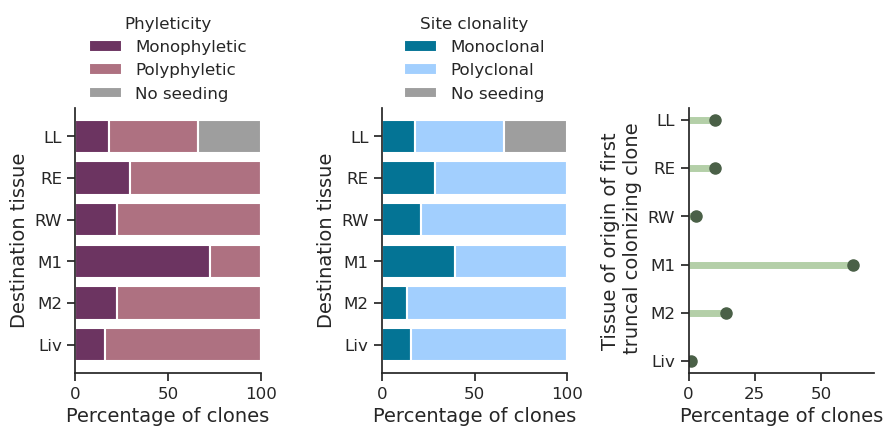

In [32]:
def horizontal_bar(proportions, desired_order, tab_colors, legend_title, output_name, ax):
    # Variables to store the bottom for each bar (cumulative stacking)
    bottoms = np.zeros(len(proportions))

    # Colors for each category
    colors = {d: c for d, c in zip(desired_order, tab_colors)}

    sns.set(style='ticks', font="Arial")

    # Plot each category (phyleticity type)
    for column_name in desired_order:
        column_data = proportions[column_name]
        ax.barh(proportions.index, column_data, left=bottoms, label=column_name, 
                color=colors[column_name], edgecolor='white', linewidth=1.5)
        bottoms += column_data.values  # Update the bottom for stacking

    # Labels and legend
    ax.set_xlabel(f'Percentage of clones', fontsize=14)
    ax.set_ylabel('Destination tissue', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Reverse y-axis tick labels
    ax.invert_yaxis()

    legend = ax.legend(title=legend_title, bbox_to_anchor=(0.5, 1.4), 
                      loc='upper center', frameon=False, fontsize=12)

    for text in legend.get_texts():
        text.set_text(text.get_text().capitalize())  # Capitalize legend text
    
    # Remove top and right axes for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Create figure with three subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 5))

# First plot - Phyleticity
phyleticity_counts = weighted_phyleticity.groupby(['tissue', 'weighted_phyleticity']).size().unstack(fill_value=0)
phyleticity_proportions = (phyleticity_counts.div(phyleticity_counts.sum(axis=1), axis=0) * 100).reindex(lt.TISSUE_ORDER)
colors = ["#6c3461", "#ae7181", "#9e9e9e"]
horizontal_bar(phyleticity_proportions, ['monophyletic', 'polyphyletic', 'no seeding'], colors,
               "Phyleticity", "phyleticity_by_tissue", ax1)

# Second plot - Clonality  
clonality_counts = weighted_clonality.groupby(['tissue', 'weighted_site clonality']).size().unstack(fill_value=0)
clonality_proportions = (clonality_counts.div(clonality_counts.sum(axis=1), axis=0) * 100).reindex(lt.TISSUE_ORDER)
colors = ["#047495", "#a2cffe", "#9e9e9e"]
horizontal_bar(clonality_proportions, ['monoclonal', 'polyclonal', 'no seeding'], colors,
               "Site clonality", "site_clonality_by_tissue", ax2)

# Third plot - Founding clone percentages
percent_founding_clones_by_tissue['tissue'] = pd.Categorical(percent_founding_clones_by_tissue['tissue'], categories=lt.TISSUE_ORDER, ordered=True)
percent_founding_clones_by_tissue = percent_founding_clones_by_tissue.sort_values('tissue')

ax3.hlines(y=percent_founding_clones_by_tissue['tissue'], xmin=0, xmax=percent_founding_clones_by_tissue['percentage_founding_clone'], 
           color='#a1c492', alpha=0.8, linewidth=5)
ax3.plot(percent_founding_clones_by_tissue['percentage_founding_clone'], percent_founding_clones_by_tissue['tissue'], 
         "o", color='#4a6047', ms=8)

ax3.set_xlim(0, 70)
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_xlabel('Percentage of clones', fontsize=14)
ax3.set_ylabel('Tissue of origin of first\n truncal colonizing clone', fontsize=14)

# Reverse y-axis tick labels for third plot
ax3.invert_yaxis()

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir,"combined_plots.png"), dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.show()
plt.close()


In [33]:
df

,clone,probability,phyleticity,tissue,highest_node_is_founding_clone,site clonality,tree_idx
0,1,1.000,monophyletic,M1,True,polyclonal,0
1,1,0.000,monophyletic,M1,False,polyclonal,1
2,1,0.000,monophyletic,M1,False,polyclonal,2
3,1,0.000,monophyletic,M1,False,polyclonal,3
4,1,0.000,monophyletic,M1,False,polyclonal,4
...,...,...,...,...,...,...,...
8202,100,0.000,no seeding,LL,True,no seeding,1
8203,100,1.000,monophyletic,RW,False,monoclonal,0
8204,100,0.000,monophyletic,RW,False,monoclonal,1
8205,100,1.000,polyphyletic,Liv,False,polyclonal,0


In [34]:
phyleticity_proportions

weighted_phyleticity,monophyletic,no seeding,polyphyletic
tissue,,,
LL,18.000,34.000,48.000
RE,29.762,0.000,70.238
RW,22.353,0.000,77.647
M1,72.527,0.000,27.473
M2,22.472,0.000,77.528
Liv,15.942,0.000,84.058
